In [160]:
%pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [106]:
x1 = [10,8,13,9,11,14,6,4,12,7,5]
y1 = [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68] 

x2 = [10,8,13,9,11,14,6,4,12,7,5]
y2 = [9.14,8.14,8.47,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]

x3 = [8,8,8,8,8,8,8,8,8,8,19]
y3 = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,5.56,7.91,6.89,12.50]

In [107]:
def media(vetor): return sum(vetor) / len(vetor)

def calcula_produto_ambos(vetX, vetY):
    # parte de cima 
    produto_ambos = 0
    for i in range(len(vetX)):
        x = vetX[i]
        y = vetY[i]

        produto_ambos = produto_ambos + ((x - media(vetX)) * (y - media(vetY)))

    return produto_ambos

def calcula_produto(vet):
    produto = 0
    for i in range(len(vet)):
        x = vet[i]

        produto = produto + ((x - media(vet)) ** 2)

    return produto

In [108]:
from math import sqrt


def correlacao(vetX, vetY):
    # parte de cima
    produto_ambos = calcula_produto_ambos(vetX, vetY)

    # parte de baixo 
    produto_x = calcula_produto(vetX)
    produto_y = calcula_produto(vetY)
    raiz_quadrada_produtos = sqrt(produto_x * produto_y)

    return produto_ambos / raiz_quadrada_produtos

In [109]:
def betaUm(vetX, vetY):
    return calcula_produto_ambos(vetX, vetY) / calcula_produto(vetX)

def betaZero(vetX, vetY, betaUm):
    return media(vetY) - (betaUm * media(vetX))

def regressao(vetX, vetY, varIndependente):
    return betaZero(vetX, vetY, betaUm(vetX, vetY)) + (betaUm(vetX, vetY) * varIndependente)

In [142]:
print("c", correlacao(x1, y1))
print("b1", betaUm(x1, y1))
print("b0", betaZero(x1, y1, betaUm(x1, y1)))

print("=" * 10)

print("c", correlacao(x2, y2))
print("b1", betaUm(x2, y2))
print("b0", betaZero(x2, y2, betaUm(x2, y2)))

print("=" * 10)

print("c", correlacao(x3, y3))
print("b1", betaUm(x3, y3))
print("b0", betaZero(x3, y3, betaUm(x3, y3)))

c 0.81642051634484
b1 0.5000909090909091
b0 3.0000909090909085
c 0.8061168716933017
b1 0.4901818181818182
b0 3.0647272727272714
c 0.8165214368885029
b1 0.4999090909090909
b0 3.0017272727272726


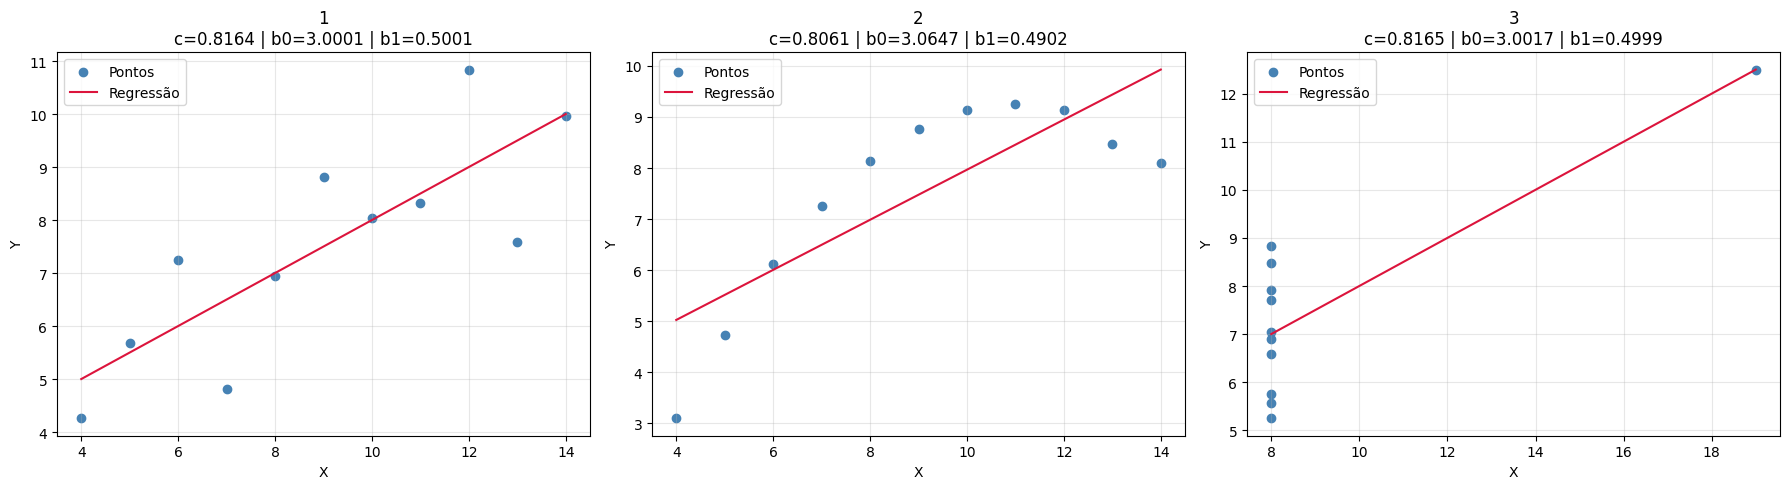

In [143]:
import matplotlib.pyplot as plt

dados = [("1", x1, y1), ("2", x2, y2), ("3", x3, y3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, x, y) in zip(axes, dados):
    c = correlacao(x, y)
    b1 = betaUm(x, y)
    b0 = betaZero(x, y, b1)

    ax.scatter(x, y, color="steelblue", label="Pontos")

    x_linha = [min(x), max(x)]
    y_linha = [b0 + b1 * xi for xi in x_linha]
    ax.plot(x_linha, y_linha, color="crimson", label="Regressão")

    ax.set_title(f"{nome}\nc={c:.4f} | b0={b0:.4f} | b1={b1:.4f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Trabalho 2

In [144]:
%pip install numpy scikit-learn pandas plotly "anywidget>=0.9.13" nbformat

Note: you may need to restart the kernel to use updated packages.


In [113]:
import scipy.io as scipy

mat = scipy.loadmat('data.mat')
data = mat['data']

In [114]:
import pandas as pd

df = pd.DataFrame(data)

df[0] = pd.to_numeric(df[0])
df[1] = pd.to_numeric(df[1])
df[2] = pd.to_numeric(df[2])

In [163]:
# Utilize o comando python .describe()para fazer uma primeira análise estatística da sua base de dados

print("describe: \n", df.describe())

describe: 
                  0          1              2
count    47.000000  47.000000      47.000000
mean   2000.680851   3.170213  340412.659574
std     794.702354   0.760982  125039.899586
min     852.000000   1.000000  169900.000000
25%    1432.000000   3.000000  249900.000000
50%    1888.000000   3.000000  299900.000000
75%    2269.000000   4.000000  384450.000000
max    4478.000000   5.000000  699900.000000


In [164]:
# A primeira coluna é o tamanho da casa, a segunda coluna é o número de quartos, e a terceira coluna é o preço da casa.

# Qual a média de preço das casas? 
print("média: ", df.mean()[2])

# Quanto custa a menor casa? 
menor_tamanho = df.min()[0]
menor_tamanho_valor = df[df[0] == menor_tamanho].values[0][2]

print("menor casa: ", menor_tamanho_valor)

# Quantos quartos tem a casa mais cara?
mais_cara = df.max()[2]
qtd_quartos = df[df[2] == mais_cara].values[0][1]

print("casa mais cara tem x quartos: ", qtd_quartos)

média:  340412.6595744681
menor casa:  179900
casa mais cara tem x quartos:  5


In [165]:
# Gere uma matriz X para as variáveis ​​independentes (que são o tamanho da casa e o número de quartos) 
# e o vetor y da variável dependente (que é o preço).

import numpy as np


preco_y = df[2].values

matrix_x = df[[0, 1]]
matrix_x.insert(0, "adicional", 1)

matrix_x_inversa = np.linalg.inv(matrix_x.values.T.dot(matrix_x.values)).dot(matrix_x.values.T)

betas = matrix_x_inversa.dot(preco_y)

b0 = betas[0]
b1 = betas[1]
b2 = betas[2]

print("betas: ", betas)

print(matrix_x.values)

betas:  [89597.9095428    139.21067402 -8738.01911233]
[[   1 2104    3]
 [   1 1600    3]
 [   1 2400    3]
 [   1 1416    2]
 [   1 3000    4]
 [   1 1985    4]
 [   1 1534    3]
 [   1 1427    3]
 [   1 1380    3]
 [   1 1494    3]
 [   1 1940    4]
 [   1 2000    3]
 [   1 1890    3]
 [   1 4478    5]
 [   1 1268    3]
 [   1 2300    4]
 [   1 1320    2]
 [   1 1236    3]
 [   1 2609    4]
 [   1 3031    4]
 [   1 1767    3]
 [   1 1888    2]
 [   1 1604    3]
 [   1 1962    4]
 [   1 3890    3]
 [   1 1100    3]
 [   1 1458    3]
 [   1 2526    3]
 [   1 2200    3]
 [   1 2637    3]
 [   1 1839    2]
 [   1 1000    1]
 [   1 2040    4]
 [   1 3137    3]
 [   1 1811    4]
 [   1 1437    3]
 [   1 1239    3]
 [   1 2132    4]
 [   1 4215    4]
 [   1 2162    4]
 [   1 1664    2]
 [   1 2238    3]
 [   1 2567    4]
 [   1 1200    3]
 [   1  852    2]
 [   1 1852    4]
 [   1 1203    3]]


Correlação entre tamanho da casa e preço:  0.8549875928781254
Correlação entre número de quartos e preço:  0.44226111704897236


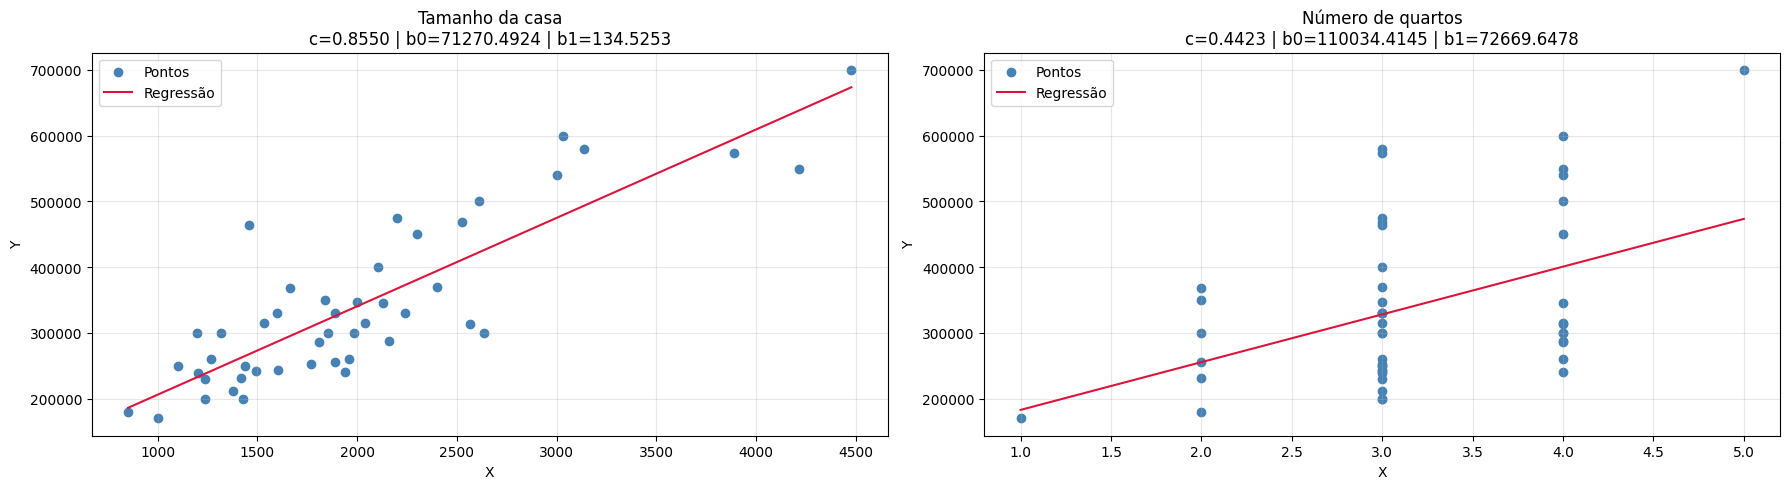

In [166]:
# Verifique a correlação e a regressão para 
# Tamanho da casa e Preço, e Número de quartos e Preço; mostre nos gráficos.

import matplotlib.pyplot as plt

corr_tamanho_preco = correlacao(df[0].values, df[2].values)
corr_quartos_preco = correlacao(df[1].values, df[2].values)

print("Correlação entre tamanho da casa e preço: ", corr_tamanho_preco)
print("Correlação entre número de quartos e preço: ", corr_quartos_preco)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
dados = [("Tamanho da casa", df[0].values, df[2].values), ("Número de quartos", df[1].values, df[2].values)]

for ax, (nome, x, y) in zip(axes, dados):
    c = correlacao(x, y)
    b1 = betaUm(x, y)
    b0 = betaZero(x, y, b1)

    ax.scatter(x, y, color="steelblue", label="Pontos")

    x_linha = [min(x), max(x)]
    y_linha = [b0 + b1 * xi for xi in x_linha]
    ax.plot(x_linha, y_linha, color="crimson", label="Regressão")

    ax.set_title(f"{nome}\nc={c:.4f} | b0={b0:.4f} | b1={b1:.4f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [167]:
# (e) - cálculo
# Calcule a Regressão Múltipla.

def griz_z_regmultipla(grid_x):
    beta1 = betaUm(df[0].values, df[2].values)
    beta0 = betaZero(df[0].values, df[2].values, beta1)
    return beta0 + beta1 * grid_x


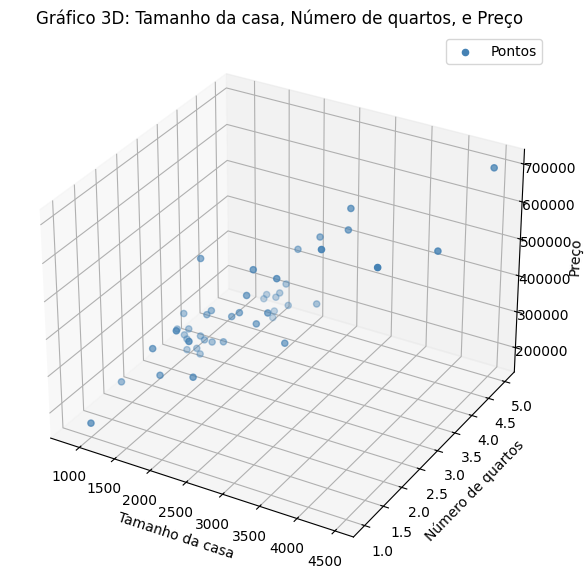

In [168]:

# (e) - gráfico
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[0].values, df[1].values, df[2].values, color="steelblue", label="Pontos")
ax.set_title("Gráfico 3D: Tamanho da casa, Número de quartos, e Preço")
ax.set_xlabel("Tamanho da casa")
ax.set_ylabel("Número de quartos")
ax.set_zlabel("Preço")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

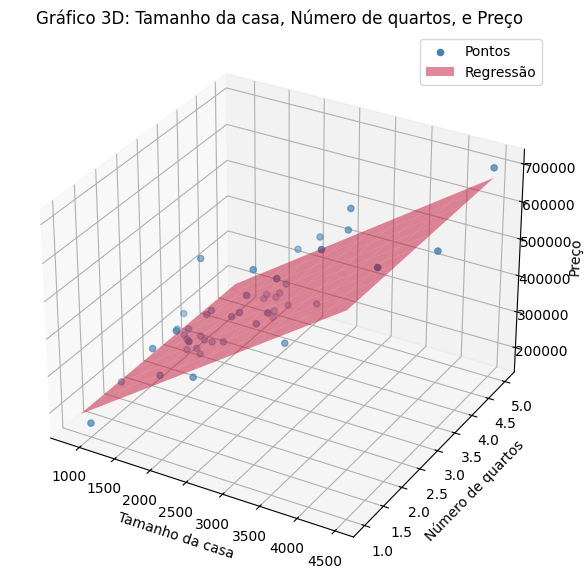

In [169]:
# (f)

import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[0].values, df[1].values, df[2].values, color="steelblue", label="Pontos")
ax.set_title("Gráfico 3D: Tamanho da casa, Número de quartos, e Preço")
ax.set_xlabel("Tamanho da casa")
ax.set_ylabel("Número de quartos")
ax.set_zlabel("Preço")

x_range = np.linspace(df[0].min(), df[0].max(), 10)
y_range = np.linspace(df[1].min(), df[1].max(), 10)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = griz_z_regmultipla(x_grid)

ax.plot_surface(x_grid, y_grid, z_grid, color='crimson', alpha=0.5, label="Regressão")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()



Coeficiente de correlação entre Tamanho da casa e Preço: 0.85
Coeficiente de correlação entre Número de quartos e Preço: 0.44


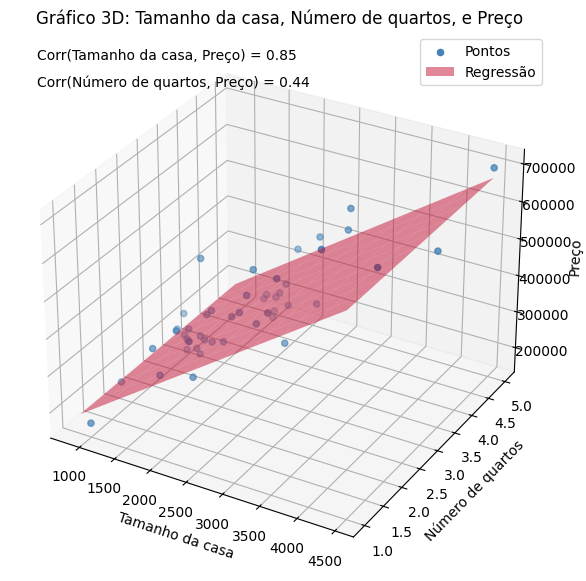

In [170]:
# (g) Mostre na figura os coeficientes de correlação entre Tamanho da casa e Preço e Número de quartos e Preço.

corr_tamanho_preco = df[0].corr(df[2])
corr_quartos_preco = df[1].corr(df[2])

print(f"Coeficiente de correlação entre Tamanho da casa e Preço: {corr_tamanho_preco:.2f}")
print(f"Coeficiente de correlação entre Número de quartos e Preço: {corr_quartos_preco:.2f}")


import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[0].values, df[1].values, df[2].values, color="steelblue", label="Pontos")
ax.set_title("Gráfico 3D: Tamanho da casa, Número de quartos, e Preço")
ax.set_xlabel("Tamanho da casa")
ax.set_ylabel("Número de quartos")
ax.set_zlabel("Preço")

x_range = np.linspace(df[0].min(), df[0].max(), 10)
y_range = np.linspace(df[1].min(), df[1].max(), 10)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = griz_z_regmultipla(x_grid)

ax.text2D(0.05, 0.95, f"Corr(Tamanho da casa, Preço) = {corr_tamanho_preco:.2f}", transform=ax.transAxes)
ax.text2D(0.05, 0.90, f"Corr(Número de quartos, Preço) = {corr_quartos_preco:.2f}", transform=ax.transAxes)


ax.plot_surface(x_grid, y_grid, z_grid, color='crimson', alpha=0.5, label="Regressão")
ax.grid(True, alpha=0.3)
ax.legend()



plt.show()


In [171]:
# Calcule o preço de uma casa que tem tamanho de 1650 e 3 quartos. O resultado deve ser igual a 293081. 
# Aumente e diminua a quantidade de número de quartos. O que acontece? Por qual motivo?

tamanho_casa = 1650
num_quartos = 3

valor_aproximado = betas[0] + betas[1] * tamanho_casa + betas[2] * num_quartos

print(f"Preço aproximado para casa com tamanho {tamanho_casa} e {num_quartos} quartos: {valor_aproximado:.0f}")

print("=" * 10)

for i in range(1, 6):
    valor_aproximado = betas[0] + betas[1] * tamanho_casa + (betas[2] * i) # aqui ó, beta 2 negativo
    print(f"Preço aproximado para casa com tamanho {tamanho_casa} e {i} quartos: {valor_aproximado:.0f}")

# o que aconteceu? por qual motivo?
# os preços diminuíram, isso acontece porque o beta 2 é negativo, ou seja, a cada quarto a mais, o preço diminui (constante o tamanho)


Preço aproximado para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado para casa com tamanho 1650 e 1 quartos: 310558
Preço aproximado para casa com tamanho 1650 e 2 quartos: 301819
Preço aproximado para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado para casa com tamanho 1650 e 4 quartos: 284343
Preço aproximado para casa com tamanho 1650 e 5 quartos: 275605


In [172]:
# Compare seus resultados com a função de regressão linear múltipla do python. Para isso você irá precisar das bibliotecas numpy e scikit-learn.

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[[0, 1]], df[2])

print("Coeficientes (sklearn): ", model.coef_)
print("Intercepto (sklearn): ", model.intercept_)

preco_aproximado_sklearn = model.predict([[tamanho_casa, num_quartos]])[0]
print(f"Preço aproximado (sklearn) para casa com tamanho {tamanho_casa} e {num_quartos} quartos: {preco_aproximado_sklearn:.0f}")

print("=" * 10)

for i in range(1, 6):
    preco_aproximado_sklearn = model.predict([[tamanho_casa, i]])[0]
    print(f"Preço aproximado (sklearn) para casa com tamanho {tamanho_casa} e {i} quartos: {preco_aproximado_sklearn:.0f}")

Coeficientes (sklearn):  [  139.21067402 -8738.01911233]
Intercepto (sklearn):  89597.90954279754
Preço aproximado (sklearn) para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado (sklearn) para casa com tamanho 1650 e 1 quartos: 310558
Preço aproximado (sklearn) para casa com tamanho 1650 e 2 quartos: 301819
Preço aproximado (sklearn) para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado (sklearn) para casa com tamanho 1650 e 4 quartos: 284343
Preço aproximado (sklearn) para casa com tamanho 1650 e 5 quartos: 275605
